In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("homeprices_banglore.csv")
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [3]:
X = df[['area','bedrooms']]
y = df['price']

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_scaled_train = scaler_x.fit_transform(x_train)
x_scaled_test = scaler_x.transform(x_test)

y_scaled_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_scaled_test = scaler_y.transform(y_test.values.reshape(-1,1))

In [5]:
from tensorflow.keras.optimizers import SGD
model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    keras.layers.Dense(5, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mse']
)

D:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
history = model.fit(
    x_scaled_train,
    y_scaled_train,
    epochs=200,          # number of epochs
    batch_size=5,        # mini batch size
    validation_data=(x_scaled_test, y_scaled_test),
    verbose=1
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.2271 - mse: 0.2271 - val_loss: 0.0980 - val_mse: 0.0980
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1975 - mse: 0.1975 - val_loss: 0.0840 - val_mse: 0.0840
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1761 - mse: 0.1761 - val_loss: 0.0729 - val_mse: 0.0729
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1567 - mse: 0.1567 - val_loss: 0.0652 - val_mse: 0.0652
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1427 - mse: 0.1427 - val_loss: 0.0594 - val_mse: 0.0594
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1308 - mse: 0.1308 - val_loss: 0.0519 - val_mse: 0.0519
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1143 - mse: 0.1143 - val_loss: 0.0495 - val_mse: 0.0495
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1086 - mse: 0.1086 - val_loss: 0.0476 - val_mse: 0.0476
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1022 - mse: 

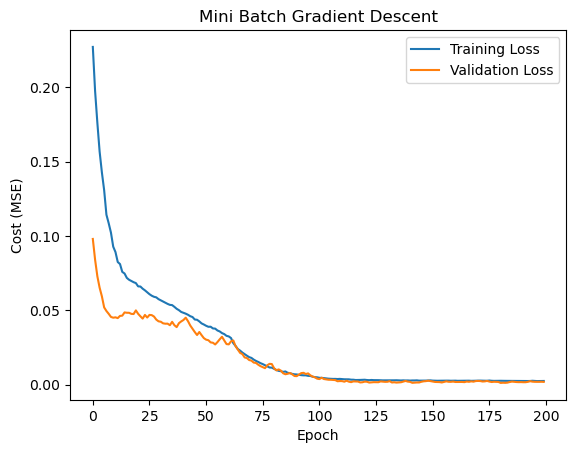

In [7]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Mini Batch Gradient Descent")

plt.legend()
plt.show()